In [2]:
!pip install xgboost
!pip install shap


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Training Set Evaluation:
RMSE: 5.32
MAE: 2.02
R² Score: 0.76

Test Set Evaluation:
RMSE: 6.36
MAE: 2.22
R² Score: 0.67


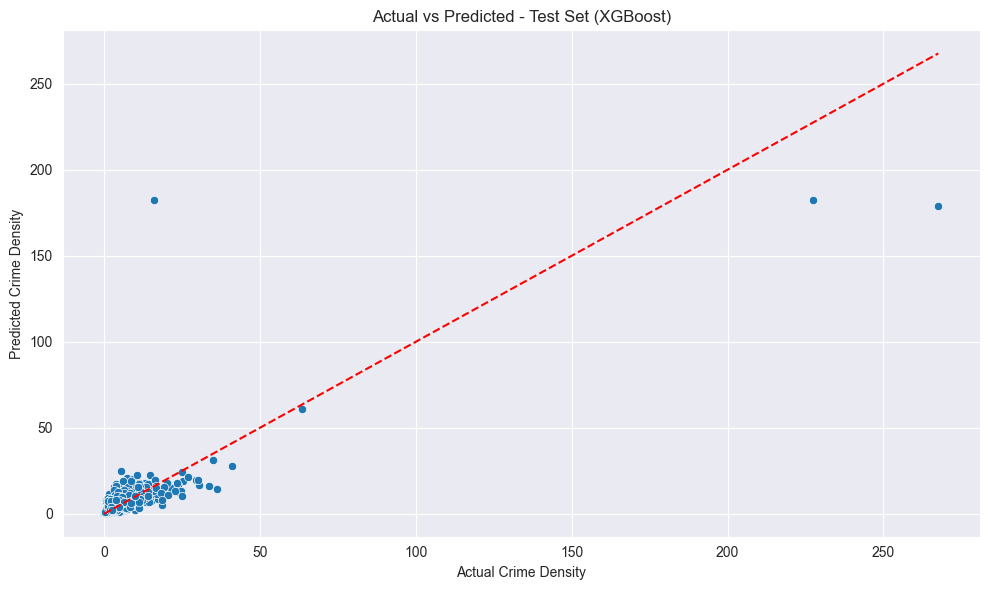

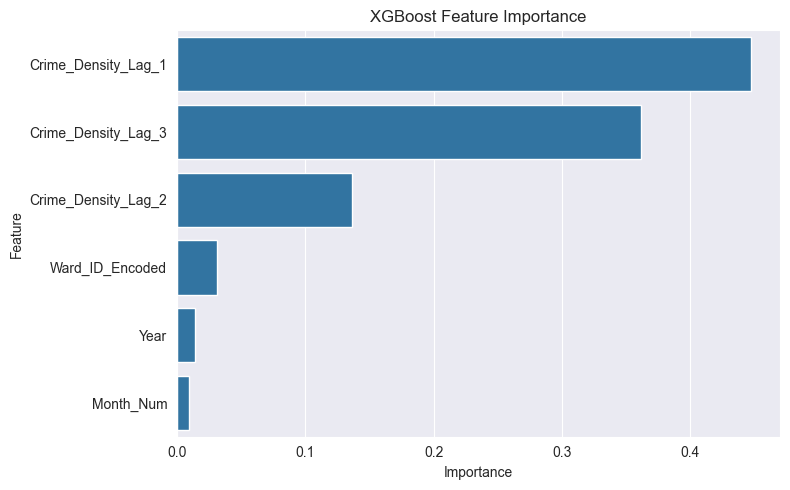

In [3]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import os

# -----------------------------
# Get the absolute path to the file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)  # Go up one directory
file_path = os.path.join(parent_dir, "output_csv_files", "ward_temporal_analysis.csv")

# Load and prepare data
df = pd.read_csv(file_path, parse_dates=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna()

# Extract year and numeric month
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month

# Rename columns to remove spaces
df = df.rename(columns={'Ward ID': 'Ward_ID'})

# Create lag features
def create_lag_features(df, lag_periods=[1, 2, 3]):
    """
    Create lag features for crime density
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe with time series data
    lag_periods : list
        List of lag periods to create
    Returns:
    --------
    pandas DataFrame with added lag features
    """
    # Sort the dataframe by Ward_ID, Year, and Month_Num
    df = df.sort_values(['Ward_ID', 'Year', 'Month_Num'])
    
    # Create lag features for each ward separately
    for ward in df['Ward_ID'].unique():
        ward_mask = df['Ward_ID'] == ward
        for lag in lag_periods:
            df.loc[ward_mask, f'Crime_Density_Lag_{lag}'] = df.loc[ward_mask, 'Monthly_Crime_Density'].shift(lag)
    
    return df

# Create lag features
df_with_lags = create_lag_features(df)

# Encode Ward_ID
le = LabelEncoder()
df_with_lags['Ward_ID_Encoded'] = le.fit_transform(df_with_lags['Ward_ID'])

# Define features
lag_features = [f'Crime_Density_Lag_{lag}' for lag in [1, 2, 3]]
features = ['Ward_ID_Encoded', 'Year', 'Month_Num'] + lag_features

# Train-test split
df_train = df_with_lags[df_with_lags['Year'] <= 2024]
df_test = df_with_lags[df_with_lags['Year'] > 2024]

# Drop rows with NaN values in any of the features
df_train = df_train.dropna(subset=features + ['Monthly_Crime_Density'])
df_test = df_test.dropna(subset=features + ['Monthly_Crime_Density'])

X_train = df_train[features]
y_train = df_train['Monthly_Crime_Density']
X_test = df_test[features]
y_test = df_test['Monthly_Crime_Density']
# -----------------------------
# XGBoost + Grid Search
# -----------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f"Best Parameters: {grid.best_params_}")

# -----------------------------
# Make Predictions
# -----------------------------
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate_model(y_true, y_pred, dataset_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Evaluation:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.2f}")
    return rmse, mae, r2

# -----------------------------
# Evaluate Model
# -----------------------------
evaluate_model(y_train, y_train_pred, "Training Set")
evaluate_model(y_test, y_test_pred, "Test Set")

# -----------------------------
# Visualization
# -----------------------------

# 1. Actual vs Predicted (Test Set)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted - Test Set (XGBoost)')
plt.xlabel('Actual Crime Density')
plt.ylabel('Predicted Crime Density')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Feature Importance
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


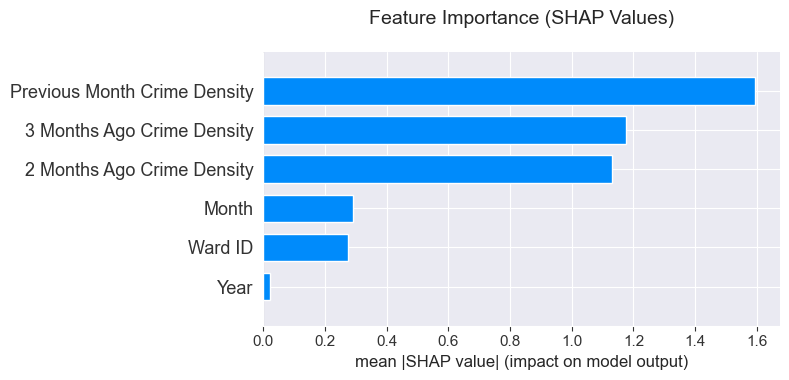

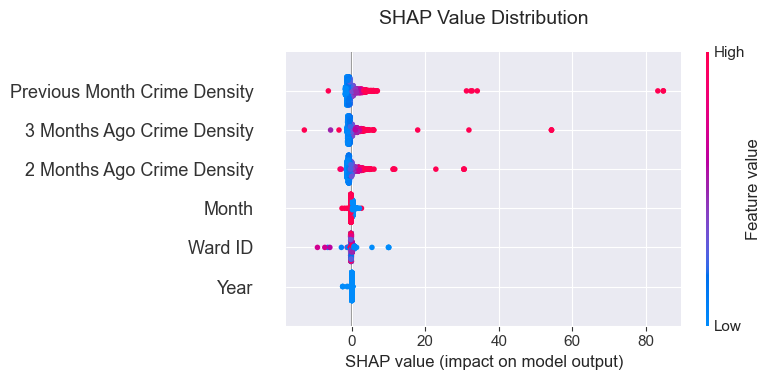

<Figure size 1000x600 with 0 Axes>

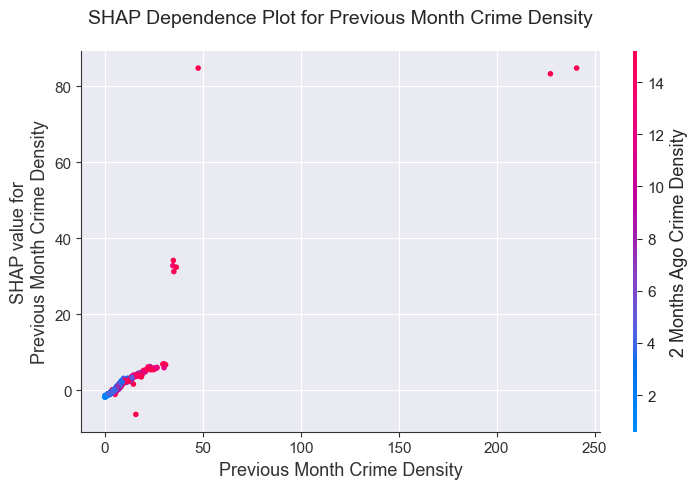

<Figure size 1000x600 with 0 Axes>

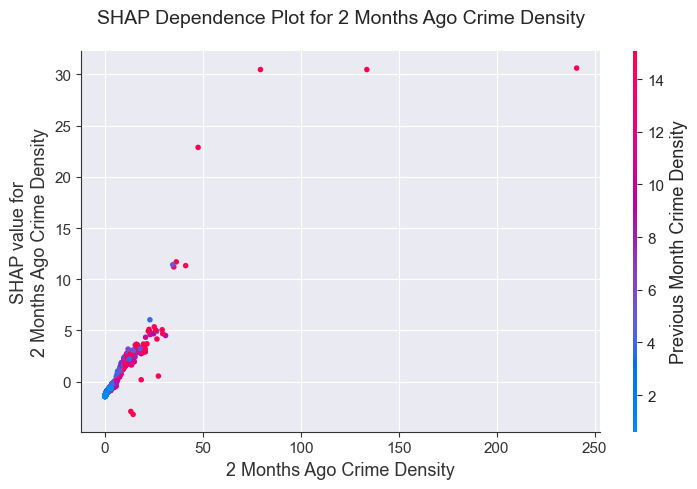

<Figure size 1000x600 with 0 Axes>

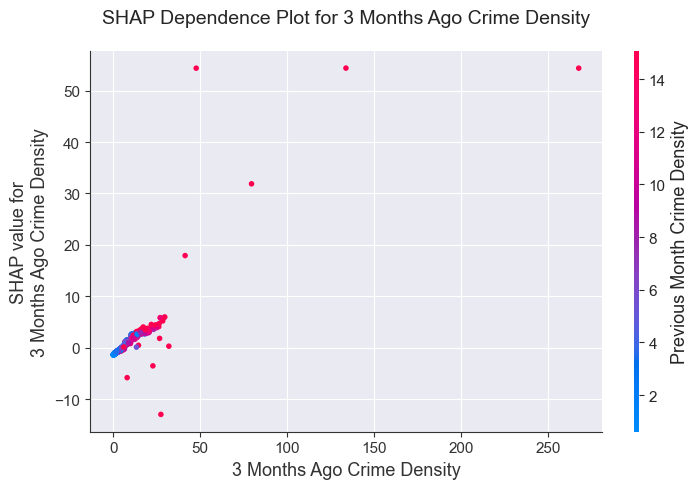

In [4]:
# Add SHAP values analysis
import shap

# Create a SHAP explainer using the best model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Create a more readable feature names dictionary
feature_names = {
    'Ward_ID_Encoded': 'Ward ID',
    'Year': 'Year',
    'Month_Num': 'Month',
    'Crime_Density_Lag_1': 'Previous Month Crime Density',
    'Crime_Density_Lag_2': '2 Months Ago Crime Density',
    'Crime_Density_Lag_3': '3 Months Ago Crime Density'
}

# Rename features in X_test for better visualization
X_test_renamed = X_test.copy()
X_test_renamed.columns = [feature_names[col] for col in X_test.columns]

# Plot summary plot with better formatting
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_renamed, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP Values)", fontsize=14, pad=20)
plt.xlabel("mean |SHAP value| (impact on model output)", fontsize=12)
plt.tight_layout()
plt.show()

# Plot detailed SHAP values with better formatting
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_renamed, show=False)
plt.title("SHAP Value Distribution", fontsize=14, pad=20)
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.tight_layout()
plt.show()

# Additional: Plot SHAP dependence plots for top features
top_features = ['Previous Month Crime Density', '2 Months Ago Crime Density', '3 Months Ago Crime Density']
for feature in top_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature, shap_values, X_test_renamed, show=False)
    plt.title(f"SHAP Dependence Plot for {feature}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()


Training Set Evaluation:
RMSE: 5.32
MAE: 2.02
R² Score: 0.76

Test Set Evaluation:
RMSE: 6.36
MAE: 2.22
R² Score: 0.67


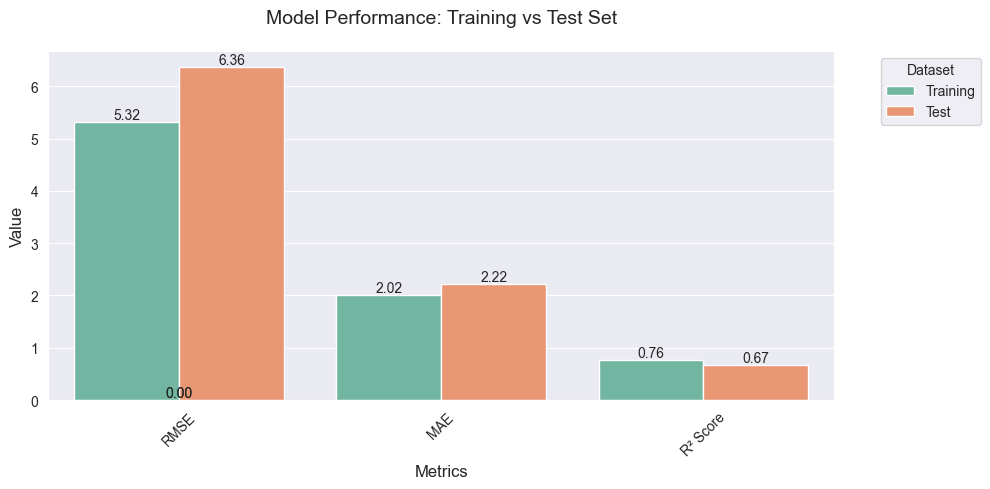

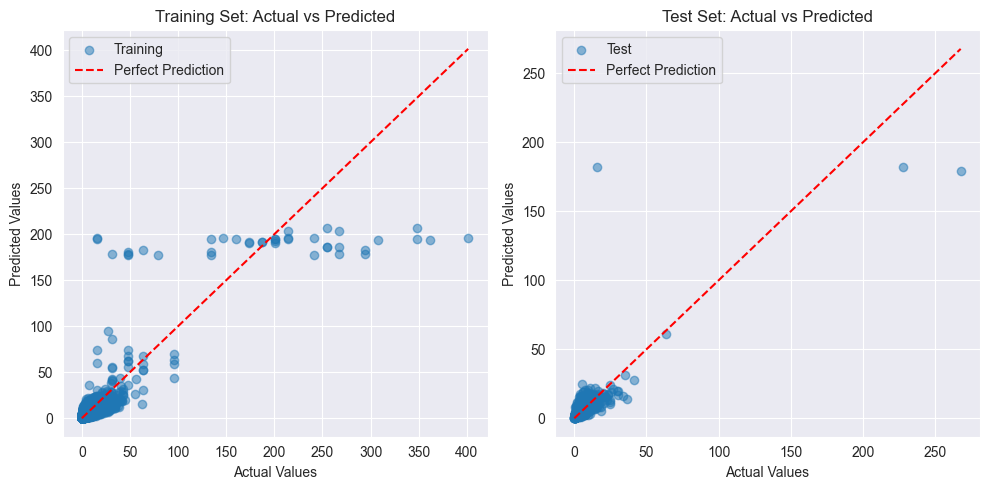

In [12]:
# Fix the test set target variable
X_train = df_train[features]
y_train = df_train['Monthly_Crime_Density']
X_test = df_test[features]
y_test = df_test['Monthly_Crime_Density']  # Fixed: use the test set's target variable

# Calculate metrics for both training and test sets
train_metrics = evaluate_model(y_train, y_train_pred, "Training Set")
test_metrics = evaluate_model(y_test, y_test_pred, "Test Set")

# Create a DataFrame for visualization
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R² Score'] * 2,
    'Value': [train_metrics[0], train_metrics[1], train_metrics[2],
              test_metrics[0], test_metrics[1], test_metrics[2]],
    'Dataset': ['Training'] * 3 + ['Test'] * 3
})

# Create the comparison plot
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Metric', y='Value', hue='Dataset', palette='Set2')

# Customize the plot
plt.title('Model Performance: Training vs Test Set', fontsize=14, pad=20)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on top of bars
for i in plt.gca().patches:
    plt.gca().annotate(f'{i.get_height():.2f}',
                      (i.get_x() + i.get_width()/2, i.get_height()),
                      ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Additional: Create a scatter plot comparing actual vs predicted for both sets
plt.figure(figsize=(10, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, label='Training')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
         'r--', label='Perfect Prediction')
plt.title('Training Set: Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()

# Test set
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, label='Test')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', label='Perfect Prediction')
plt.title('Test Set: Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()

plt.tight_layout()
plt.show()
# doesnt seem underfitting or overfitting

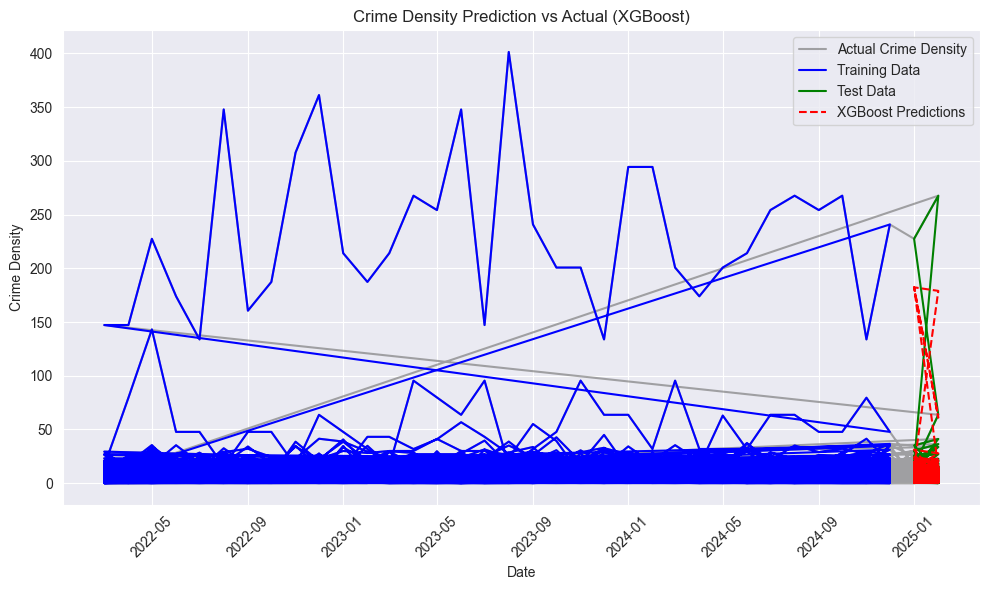

In [9]:

# Time Series Plot
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(df_with_lags['Month'], df_with_lags['Monthly_Crime_Density'], 
         label='Actual Crime Density', color='gray', alpha=0.7)

# Plot training data
train_mask = df_with_lags['Year'] <= 2024
plt.plot(df_with_lags.loc[train_mask, 'Month'], 
         df_with_lags.loc[train_mask, 'Monthly_Crime_Density'],
         label='Training Data', color='blue')

# Plot test data
test_mask = df_with_lags['Year'] > 2024
plt.plot(df_with_lags.loc[test_mask, 'Month'], 
         df_with_lags.loc[test_mask, 'Monthly_Crime_Density'],
         label='Test Data', color='green')

# Plot predictions
plt.plot(df_with_lags.loc[test_mask, 'Month'], 
         y_test_pred,
         label='XGBoost Predictions', color='red', linestyle='--')

plt.title('Crime Density Prediction vs Actual (XGBoost)')
plt.xlabel('Date')
plt.ylabel('Crime Density')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()